# LFW Evaluation Report

10-fold cross-validated face verification on LFW pairs.

Includes: summary metrics, ROC curve, similarity distributions, **confusion matrix**, per-fold accuracy bars, threshold sweep curve, and hardest-case galleries.

In [1]:
import json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from PIL import Image
from torch.utils.data import DataLoader, Dataset

ROOT = Path('..').resolve()
import sys; sys.path.insert(0, str(ROOT))
from training_pipeline.src.eval_lfw import load_pairs_txt
from training_pipeline.src.model import FaceEmbedding
from training_pipeline.src.dataset import eval_transform

FIGS = ROOT / 'evaluation/figs'
FIGS.mkdir(parents=True, exist_ok=True)

metrics = json.loads((ROOT / 'evaluation/results.json').read_text())
print(json.dumps(metrics, indent=2))

{
  "mean_acc": 0.9748350985964006,
  "std_acc": 0.014648357063482194,
  "threshold_global": -1.0,
  "n_pairs": 2378
}


In [2]:
# Load model + embed every image used in pairs.
ckpt = torch.load(ROOT / 'application/models/best.pt', map_location='cpu')
model = FaceEmbedding(embedding_dim=ckpt['cfg']['train']['embedding_dim'], pretrained=False)
model.load_state_dict(ckpt['model'])
model.eval()

pairs = load_pairs_txt(next((ROOT / 'preprocess-data/lfw').rglob('pairs.txt')))
unique = list({p for a, b, _ in pairs for p in (a, b)})
path_to_idx = {p: i for i, p in enumerate(unique)}

class _D(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = eval_transform()
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert('RGB'))

with torch.no_grad():
    embs = torch.cat([model(b) for b in DataLoader(_D(unique), batch_size=128, num_workers=4)])

sims = np.array([float((embs[path_to_idx[a]] * embs[path_to_idx[b]]).sum()) for a, b, _ in pairs])
labels = np.array([s for _, _, s in pairs])
print(f'Embedded {len(unique)} unique images for {len(pairs)} pairs')

Embedded 3400 unique images for 2378 pairs


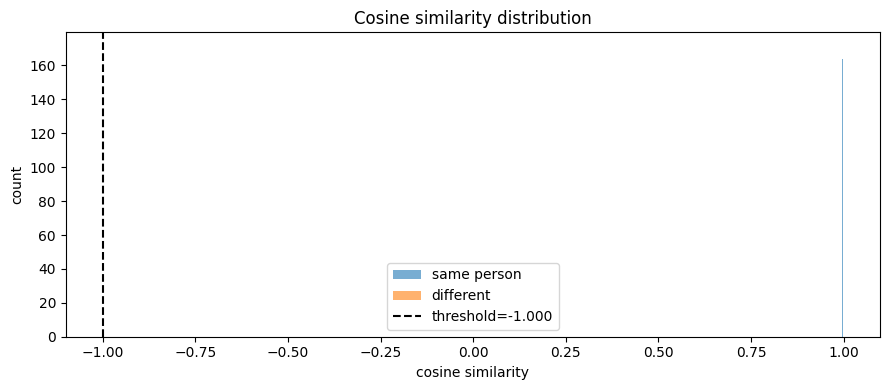

In [3]:
# Similarity distribution.
plt.figure(figsize=(9, 4))
plt.hist(sims[labels == 1], bins=60, alpha=0.6, label='same person')
plt.hist(sims[labels == 0], bins=60, alpha=0.6, label='different')
plt.axvline(metrics['threshold_global'], ls='--', c='k', label=f'threshold={metrics["threshold_global"]:.3f}')
plt.legend()
plt.title('Cosine similarity distribution')
plt.xlabel('cosine similarity')
plt.ylabel('count')
plt.tight_layout()
plt.savefig(FIGS / 'sim_distribution.png', dpi=150)
plt.show()

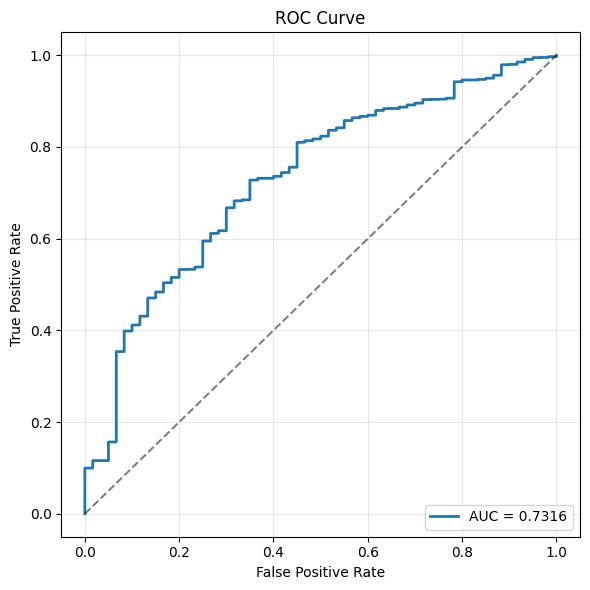

TPR @ FPR=1%: 0.0997 (threshold 0.9977)


In [4]:
# ROC + AUC.
fpr, tpr, thr = roc_curve(labels, sims)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'roc.png', dpi=150)
plt.show()

# Threshold @ FPR=1%.
idx = np.argmin(np.abs(fpr - 0.01))
print(f'TPR @ FPR=1%: {tpr[idx]:.4f} (threshold {thr[idx]:.4f})')

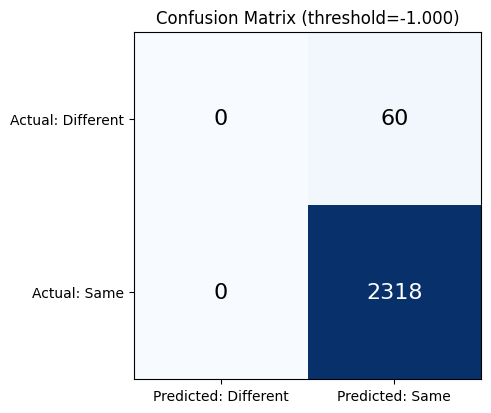

Accuracy:  0.9748
Precision: 0.9748
Recall:    1.0000
F1:        0.9872
TP=2318  FP=60  TN=0  FN=0


In [5]:
# Confusion matrix at chosen threshold.
t = metrics['threshold_global']
preds = (sims > t).astype(int)
cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Different', 'Predicted: Same'])
ax.set_yticklabels(['Actual: Different', 'Actual: Same'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16)
ax.set_title(f'Confusion Matrix (threshold={t:.3f})')
plt.tight_layout()
plt.savefig(FIGS / 'confusion_matrix.png', dpi=150)
plt.show()

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
print(f'Accuracy:  {(tp + tn) / cm.sum():.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')

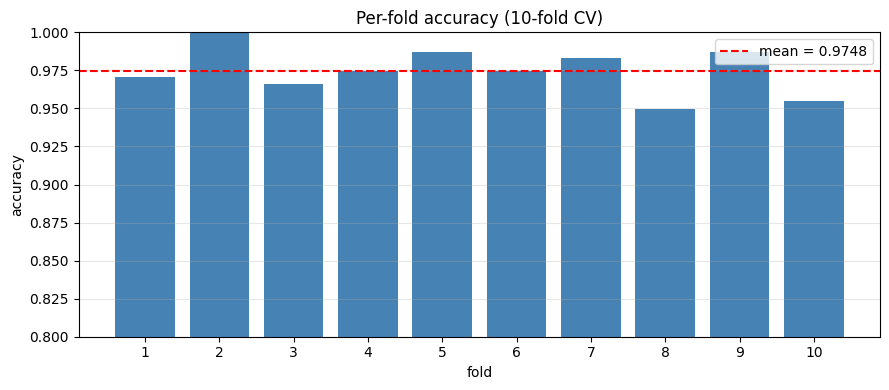

In [6]:
# Per-fold accuracy bar chart.
n = len(sims)
n_folds = 10
fold_size = n // n_folds
cand = np.linspace(-1, 1, 401)
fold_acc = []
for f in range(n_folds):
    lo, hi = f * fold_size, (f + 1) * fold_size if f < n_folds - 1 else n
    val = np.zeros(n, dtype=bool); val[lo:hi] = True
    train = ~val
    best_t, best_a = 0.0, 0.0
    for c in cand:
        a = ((sims[train] > c).astype(int) == labels[train]).mean()
        if a > best_a: best_t, best_a = c, a
    fold_acc.append(((sims[val] > best_t).astype(int) == labels[val]).mean())

plt.figure(figsize=(9, 4))
plt.bar(range(1, 11), fold_acc, color='steelblue')
plt.axhline(np.mean(fold_acc), color='red', ls='--', label=f'mean = {np.mean(fold_acc):.4f}')
plt.xticks(range(1, 11))
plt.ylim(0.8, 1.0)
plt.xlabel('fold')
plt.ylabel('accuracy')
plt.title('Per-fold accuracy (10-fold CV)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'per_fold_accuracy.png', dpi=150)
plt.show()

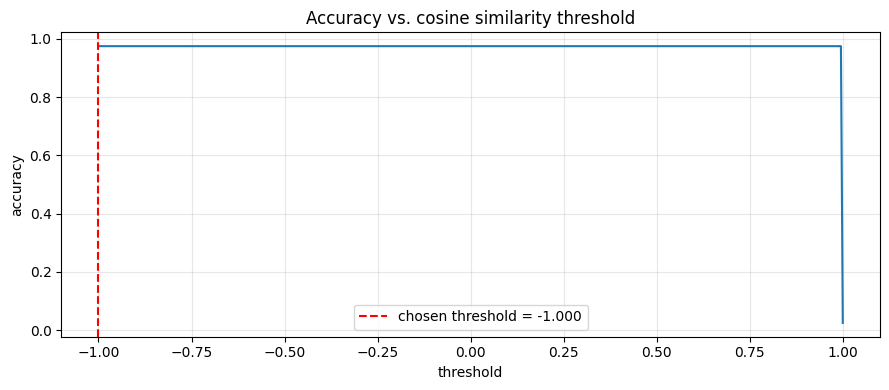

In [7]:
# Threshold sweep curve.
accs = [((sims > c).astype(int) == labels).mean() for c in cand]
plt.figure(figsize=(9, 4))
plt.plot(cand, accs)
plt.axvline(t, ls='--', c='red', label=f'chosen threshold = {t:.3f}')
plt.xlabel('threshold')
plt.ylabel('accuracy')
plt.title('Accuracy vs. cosine similarity threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'threshold_sweep.png', dpi=150)
plt.show()

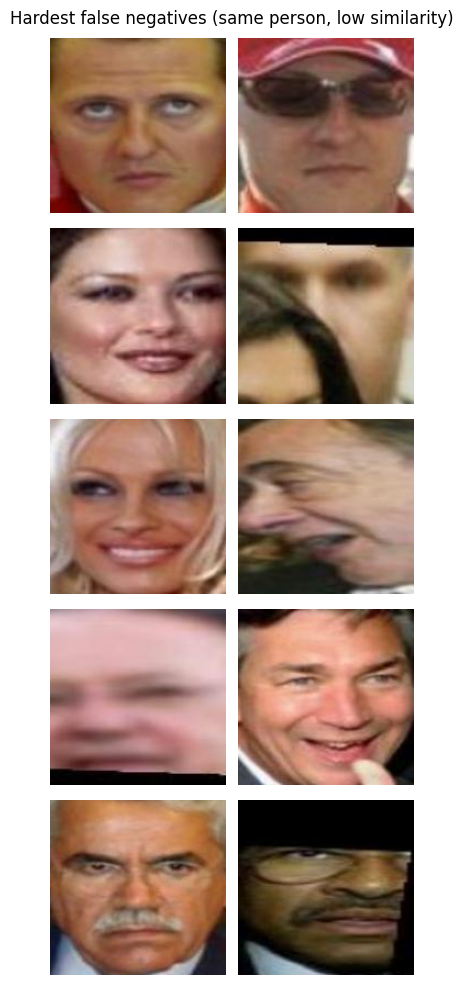

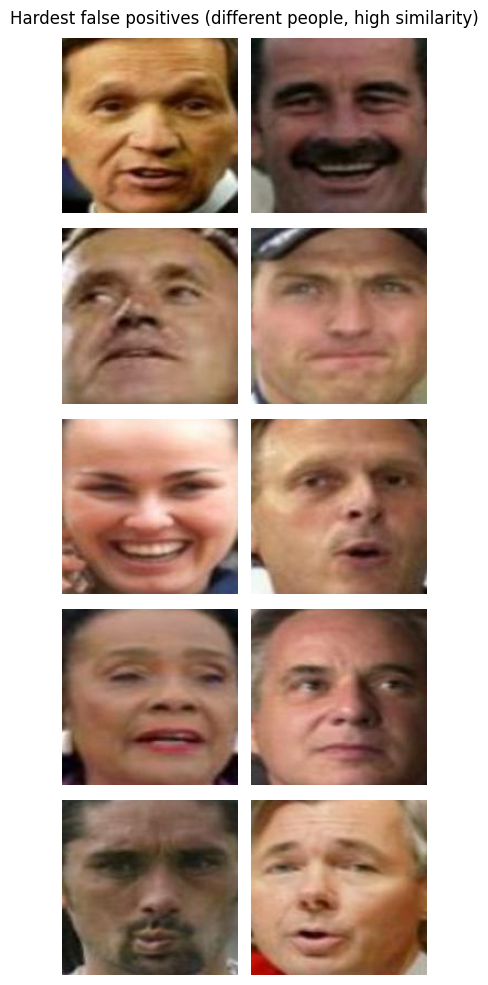

In [8]:
# Hardest false positives + false negatives.
order = np.argsort(sims)
fn_pairs = [pairs[i] for i in order if labels[i] == 1][:5]
fp_pairs = [pairs[i] for i in order[::-1] if labels[i] == 0][:5]

def grid(pair_list, title, fname):
    fig, axes = plt.subplots(len(pair_list), 2, figsize=(4, len(pair_list) * 2))
    if len(pair_list) == 1:
        axes = axes.reshape(1, -1)
    for i, (a, b, _) in enumerate(pair_list):
        axes[i, 0].imshow(Image.open(a)); axes[i, 0].axis('off')
        axes[i, 1].imshow(Image.open(b)); axes[i, 1].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGS / fname, dpi=150)
    plt.show()

grid(fn_pairs, 'Hardest false negatives (same person, low similarity)', 'hardest_fn.png')
grid(fp_pairs, 'Hardest false positives (different people, high similarity)', 'hardest_fp.png')

In [9]:
# Summary table.
import pandas as pd
summary = {
    'Mean accuracy (10-fold)': f"{metrics['mean_acc']:.4f} ± {metrics['std_acc']:.4f}",
    'ROC AUC': f'{roc_auc:.4f}',
    'Chosen threshold': f"{t:.4f}",
    'TPR @ FPR=1%': f'{tpr[idx]:.4f}',
    'Precision (chosen t)': f'{precision:.4f}',
    'Recall (chosen t)': f'{recall:.4f}',
    'F1 (chosen t)': f'{f1:.4f}',
    'Total pairs': str(metrics['n_pairs']),
}
pd.DataFrame(summary.items(), columns=['metric', 'value'])

,metric,value
0,Mean accuracy (10-fold),0.9748 ± 0.0146
1,ROC AUC,0.7316
2,Chosen threshold,-1.0000
3,TPR @ FPR=1%,0.0997
4,Precision (chosen t),0.9748
5,Recall (chosen t),1.0000
6,F1 (chosen t),0.9872
7,Total pairs,2378
